(01-03-williams-ddm)=

# Williams en het dividend discount model

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1938–1959.

**Wat we al weten.** Uit [](#01-02-bachelier) komt een beschrijving van koersen:
prijsveranderingen zijn vrijwel onvoorspelbaar, en hun spreiding groeit met
$\sqrt{t}$. Cowles liet zien dat beleggingsadviseurs de markt niet verslaan.
Kendall vond dat de samenhang tussen opeenvolgende koersveranderingen te zwak is
om mee te voorspellen. Dat zijn uitspraken over *veranderingen*: er was een
theorie van de ruis, maar geen theorie van het koersniveau.

**Welke vraag staat open.** Wat is een aandeel waard: welke grootheid maakt van
een koers meer dan een getal waarover mensen het toevallig eens zijn?
```

## Overzicht

Wat is een aandeel waard? Williams antwoordde in 1938: de contante waarde van
alle dividenden die het ooit uitkeert, verdisconteerd tegen een vaste
discontovoet. De data verwerpen dat antwoord in die vorm: niet de verwachte
dividenden maar de discontovoet beweegt. In deze lecture:

- leiden we uit de definitie van rendement een *boekhoudkundige identiteit* af.
  Die kan niet fout zijn, net zo min als "bezit is schuld plus eigen vermogen";
- voegen we de aanname van Williams toe, een constante discontovoet $r$. Dat
  *model van Williams* kan wel fout zijn;
- werken we het uit tot het Gordon-groeimodel $p = d_1/(r-g)$, en laten we met de
  PVGO zien wanneer groei waarde toevoegt;
- simuleren we hoe breed een waardering uitvalt als $g$ uit historische data
  wordt geschat;
- toetsen we op Shillers data waar het model toetsbaar is: bij constante $r$ moet
  een hoge prijs-dividend-ratio door snelle dividendgroei gevolgd worden.

In 1938 publiceerde John Burr Williams *The Theory of Investment Value*
{cite}`Williams1938`, een proefschrift dat hij bij Schumpeter in Harvard
verdedigde. De kern is één zin: een investering is de contante waarde waard van
de uitkeringen die zij ooit zal doen. De gangbare praktijk was toen om de winst
met een gewoontegetal te vermenigvuldigen. Williams verving dat getal door een
som, en wie het oneens was, moest voortaan zeggen *waarover*. Gordon en Shapiro
brachten het idee in de jaren vijftig met een gesloten formule de praktijk in
{cite}`GordonShapiro1956,Gordon1959`. Met Williams volgt een prijs voor het eerst
uit een model en niet uit een gewoonte. Daarom begint het tijdvak hier.

## Intuïtie: waarom zou dit waar zijn?

Een aandeel is een stuk papier. Het geeft geen nut, het gaat niet stuk, en
niemand kan erin wonen. Het enige wat het ooit doet, is af en toe geld uitkeren.
Alles wat een aandeel waard is, moet dus uit die uitkeringen komen, of uit de
prijs waarvoor de eigenaar het later verkoopt.

Maar de koper van later staat voor dezelfde vraag. Ook hij kan alleen rekenen op
uitkeringen en op een nóg latere verkoopprijs. Wie die redenering doorzet, ziet
de verkoopprijs steeds verder de toekomst in schuiven, tot hij verdwijnt. Wat
overblijft, is de stroom dividenden.

De kracht van die gedachte zit in wat zij *uitsluit*. Een aandeel ontleent geen
waarde aan het feit dat anderen het willen hebben. Een koers is niet hoog omdat
hij de laatste jaren hoog was. Williams gebruikte zelf het beeld van een
boomgaard, die de appels waard is die eraan komen. Wat een ander voor een
boomgaard betaalde, doet er in die redenering niet toe.

Om er een getal van te maken, zijn twee dingen nodig: een verwachting over de
dividenden, en een tarief waartegen een euro van volgend jaar wordt omgerekend
naar een euro van vandaag. Dat tarief heet de *discontovoet*. Williams werkte de
dividenden in honderden bladzijden uit, met tabellen die hij met de hand
uitrekende. De discontovoet nam hij in zijn waarderingen als gegeven. Een theorie
die zegt welk tarief bij welk risico hoort, kwam pas een kwarteeuw later, met het
CAPM.

Zonder zo'n theorie zegt de som op zichzelf weinig. Met dividendverwachtingen en
discontovoet volgt de prijs, maar met prijs en dividendverwachtingen volgt net zo
goed de discontovoet. De gedachte doet pas een voorspelling zodra de discontovoet
vastligt. Een aandeel kan dan alleen duur zijn ten opzichte van zijn dividend
omdat de markt snelle dividendgroei verwacht.

We verwachten dus: een hoge
prijs-dividend-ratio (de prijs gedeeld door het dividend) wordt gevolgd door snel
stijgende dividenden. De theorie leidt die voorspelling af, en de replicatie
toetst haar.

## Toy-voorbeeld: drie jaar dividenden, met de hand verdisconteerd

Het kleinste voorbeeld van Williams' som is één aandeel met twee groeifasen. Eerst
de imports-cel, de enige van deze lecture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

**Opzet.** Een bedrijf heeft zojuist een dividend van $d_0 = 1{,}00$ per aandeel
uitgekeerd. De discontovoet is $r = 10\%$.

| periode | groei van het dividend | discontovoet |
|---|---|---|
| jaar 1 tot en met 3 | 10% per jaar | 10% |
| vanaf jaar 4, voor altijd | 5% per jaar | 10% |

**Het recept.** De prijs is de som van de verdisconteerde dividenden. Voor het
deel dat voor altijd met $g$ groeit, gebruiken we één formule die de theorie
straks afleidt: een stroom die volgend jaar $d$ uitkeert en daarna met $g$
groeit, is vandaag $d/(r-g)$ waard.

**Stap 1.** De eerste drie dividenden zijn $d_1 = 1{,}10$, $d_2 = 1{,}21$ en
$d_3 = 1{,}331$.

**Stap 2.** Verdisconteren gaat per jaar met een factor $1{,}10$. Omdat de groei in
deze fase gelijk is aan de discontovoet, is elke term één:
$1{,}10/1{,}10 = 1{,}21/1{,}21 = 1{,}331/1{,}331 = 1{,}00$. Samen zijn de eerste
drie dividenden $3{,}00$ waard.

**Stap 3.** Vanaf jaar 4 groeit het dividend met 5%, te beginnen bij
$d_4 = 1{,}331 \times 1{,}05 = 1{,}39755$.

**Stap 4.** Volgens het recept is die stroom op $t=3$ waard
$d_4/(r-g) = 1{,}39755/0{,}05 = 27{,}951$. Dat is de *eindwaarde*: de verwachte
verkoopprijs van het aandeel op $t=3$.

**Stap 5.** Terugrekenen naar vandaag met $1{,}10^3 = 1{,}331$ geeft
$27{,}951/1{,}331 = 21{,}00$. Dat is exact, want $1{,}331 \times 21 = 27{,}951$.

**Stap 6.** De prijs is $p_0 = 3{,}00 + 21{,}00 = 24{,}00$, en de
prijs-dividend-ratio is $\mathrm{PD}_0 = 24{,}00/1{,}00 = 24$.

De codecel rekent dezelfde stappen na en zet de handberekening ernaast.

In [2]:
d0, r, g_early, g_late, n = 1.00, 0.10, 0.10, 0.05, 3

years = np.arange(1, n + 1)
dividends = d0 * (1 + g_early) ** years          # d_1, d_2, d_3
discounted = dividends / (1 + r) ** years       # contante waarde per jaar

d_next = dividends[-1] * (1 + g_late)           # d_4
terminal = d_next / (r - g_late)                # eindwaarde op t = 3 (het recept)
terminal_pv = terminal / (1 + r) ** n           # eindwaarde teruggerekend naar t = 0
price = discounted.sum() + terminal_pv

hand = pd.Series({
    "d_1": 1.10, "d_2": 1.21, "d_3": 1.331,
    "contante waarde d_1 t/m d_3": 3.00,
    "d_4": 1.39755,
    "eindwaarde op t=3": 27.951,
    "eindwaarde op t=0": 21.00,
    "prijs p_0": 24.00,
    "aandeel eindwaarde": 0.875,
})
code = pd.Series({
    "d_1": dividends[0], "d_2": dividends[1], "d_3": dividends[2],
    "contante waarde d_1 t/m d_3": discounted.sum(),
    "d_4": d_next,
    "eindwaarde op t=3": terminal,
    "eindwaarde op t=0": terminal_pv,
    "prijs p_0": price,
    "aandeel eindwaarde": terminal_pv / price,
})
pd.DataFrame({"met de hand": hand, "code": code}).round(5)

,met de hand,code
d_1,1.10000,1.10000
d_2,1.21000,1.21000
d_3,1.33100,1.33100
contante waarde d_1 t/m d_3,3.00000,3.00000
d_4,1.39755,1.39755
eindwaarde op t=3,27.95100,27.95100
eindwaarde op t=0,21.00000,21.00000
prijs p_0,24.00000,24.00000
aandeel eindwaarde,0.87500,0.87500


De twee kolommen zijn gelijk, dus de code doet wat de handberekening doet. Van
de prijs van $24{,}00$ komt $21{,}00$ uit alles na jaar 3: 87,5%.

Wie het toy narekent, weet nu dat de prijs vooral uit de eindwaarde komt, en dat
die eindwaarde door een klein getal wordt gedeeld: $r - g = 5$ procentpunt. Een
waardering is dus vooral een uitspraak over een verre toekomst waarover niemand
iets weet.

## Theorie

We leiden vier dingen af. Eerst de boekhoudkundige identiteit, die uit de
definitie van rendement volgt, en daaruit met één aanname, een constante
discontovoet, het model van Williams. De transversaliteitsvoorwaarde maakt er een
oneindige som van, de kern van deze lecture. Daarna het Gordon-model, de gesloten vorm die
het toy-voorbeeld als recept gebruikte, en de PVGO, die zegt wanneer groei waarde
toevoegt. Ten slotte de prijs-dividend-ratio, de plek waar het model toetsbaar
wordt.

### Opzet en aannames

Deze subsectie legt vast wat een rendement is en welke aanname Williams daaraan
toevoegt. Er is één aandeel dat op elk tijdstip $t$ een dividend $d_t \ge 0$
uitkeert, en de prijs $p_t$ is eindig. De prijs is *ex dividend*: wie op $t$ voor
$p_t$ koopt, krijgt $d_{t+1}$ en niet $d_t$. Het bruto rendement van $t$ naar
$t+1$ is dan

```{math}
:label: eq-williams-ddm-rendement
R_{t+1} = \frac{p_{t+1} + d_{t+1}}{p_t}.
```

In woorden: het rendement is wat de koper morgen terugkrijgt, dividend plus
verkoopprijs, gedeeld door wat hij vandaag betaalde. Dit is een definitie, geen
aanname.

De aanname van Williams: er is een getal $r$ zodat voor elke periode
$\E_t[R_{t+1}] = 1 + r$, met $\E_t$ de verwachting op grond van wat op $t$ bekend
is. Het *verwachte* rendement is constant, niet het gerealiseerde. In dit model
is de discontovoet $r$ hetzelfde als het verwachte netto rendement. We noemen hem
verder alleen de discontovoet.

Voor Amerikaanse aandelen is hij reëel ongeveer
8,4% per jaar als gewoon gemiddelde. Shillers data, waarop de simulatie kalibreert,
geven 6,8% als gemiddeld logrendement. Het toy-voorbeeld rekent met een rond getal,
10%.

De notatie is die van [](#00-00-setup): $R = 1 + r$ is bruto, $r$ netto en simpel,
en $p_t$ en $d_t$ zijn niveaus in euro. Dat is een wissel ten opzichte van
[](#01-02-bachelier), waar kleine letters logs waren: de som van Williams telt
bedragen op, geen logs. Logs komen pas in de replicatie terug, en daar staat het
er steeds bij.

### Van de definitie van rendement naar de contante waarde

De prijs van vandaag is de contante waarde van de dividenden tot een horizon $K$,
plus de verdisconteerde verkoopprijs op $K$. Dat volgt eerst uit de definitie van
rendement alleen, en daarna, met verwachte waarden, uit het model van Williams.

*Waarom zou dit waar zijn?* Een koper betaalt vandaag een prijs en krijgt morgen
een dividend en een verkoopprijs. Wat hij vandaag betaalt, is dus de opbrengst van
morgen, gedeeld door het rendement. De koper van morgen doet hetzelfde met de
opbrengst van overmorgen. Zo schuift de verkoopprijs steeds verder weg, en blijven
de dividenden over. Hoe hoger de dividenden, hoe hoger de prijs. Hoe hoger het
rendement waarmee ze verdisconteerd worden, hoe lager.

**De boekhoudkundige identiteit.** Schrijf [](#eq-williams-ddm-rendement) als
$p_t = (d_{t+1} + p_{t+1})/R_{t+1}$ en vul dezelfde gelijkheid in voor $p_{t+1}$,
$p_{t+2}$, enzovoort. Na $K$ stappen staat er

$$
p_t = \sum_{j=1}^{K} \frac{d_{t+j}}{R_{t+1} \cdots R_{t+j}}
      + \frac{p_{t+K}}{R_{t+1} \cdots R_{t+K}} .
$$

In woorden: de prijs is de som van de dividenden tot $K$ en de verkoopprijs op
$K$, verdisconteerd met de rendementen die werkelijk worden behaald. Deze
identiteit neemt niets aan en kan daarom door geen enkele data worden verworpen.
Het model van Williams kan dat wel. Dat onderscheid draagt de hele lecture: de
replicatie toetst het model, niet de identiteit.

**Het model van Williams.** Neem de verwachting op $t$ van
[](#eq-williams-ddm-rendement) en gebruik $\E_t[R_{t+1}] = 1+r$:

$$
p_t = \frac{\E_t\!\left[d_{t+1} + p_{t+1}\right]}{1+r}.
$$

De prijs is de verwachte opbrengst van morgen, één periode verdisconteerd. Deze
vergelijking geldt op elk tijdstip, dus ook op $t+1$. We substitueren
$p_{t+1} = \E_{t+1}[d_{t+2} + p_{t+2}]/(1+r)$ en gebruiken de wet van iteratieve
verwachtingen, $\E_t[\E_{t+1}[\cdot]] = \E_t[\cdot]$: wat we vandaag verwachten
dat we morgen zullen verwachten, verwachten we vandaag al. Na $K$ stappen staat
er de eindige versie van het model:

```{math}
:label: eq-williams-ddm-eindig
p_t = \sum_{j=1}^{K} \frac{\E_t\!\left[d_{t+j}\right]}{(1+r)^{j}}
      + \frac{\E_t\!\left[p_{t+K}\right]}{(1+r)^{K}} .
```

In woorden: de prijs is de contante waarde van de verwachte dividenden tot $K$,
plus de verdisconteerde verwachte verkoopprijs op $K$, de eindwaarde. Het
toy-voorbeeld is het geval $K = 3$: $3{,}00$ aan dividenden plus $21{,}00$ aan
verdisconteerde eindwaarde.

### Het kernresultaat: transversaliteit en het dividend discount model

Laat de horizon $K$ naar oneindig gaan. Als de verdisconteerde eindwaarde dan
verdwijnt, is de prijs de som van alle verwachte dividenden.

*Waarom zou dit waar zijn?* Een koper die een aandeel over $K$ jaar
doorverkoopt, betaalt vandaag ook voor de verdisconteerde eindwaarde. Groeit de
verwachte verkoopprijs trager dan $r$, zoals in het toy met 5% tegen 10%, dan
krimpt dat deel naarmate $K$ groeit, en blijven alleen de dividenden over. De
transversaliteitsvoorwaarde eist dat. Verwacht een koper dat de prijs zelf in
het tempo $r$ blijft stijgen, dan krimpt het deel niet, en betaalt hij meer dan
de dividenden rechtvaardigen.

:::{prf:theorem} Dividend discount model
:label: thm-williams-ddm-ddm

Als $\E_t[R_{t+1}] = 1+r$ voor alle $t$ met $r > 0$, en als de
transversaliteitsvoorwaarde

```{math}
:label: eq-williams-ddm-transversaliteit
\lim_{K \to \infty} \frac{\E_t\!\left[p_{t+K}\right]}{(1+r)^{K}} = 0
```

geldt, dan is

```{math}
:label: eq-williams-ddm-ddm
p_t = \sum_{j=1}^{\infty} \frac{\E_t\!\left[d_{t+j}\right]}{(1+r)^{j}} .
```
:::

[](#eq-williams-ddm-transversaliteit) zegt dat de verdisconteerde eindwaarde in de
verre toekomst naar nul gaat. [](#eq-williams-ddm-ddm) is het model van Williams
in zijn definitieve vorm: de prijs is de som van alle verwachte dividenden, elk
verdisconteerd met $r$. De voorwaarde hoort bij het model. De identiteit
gebruiken we alleen met een eindige horizon $K$, en dan neemt zij niets aan.

:::{prf:proof}
Neem in [](#eq-williams-ddm-eindig) de limiet $K \to \infty$. Omdat dividenden
niet-negatief zijn, zijn de partiële sommen niet-dalend: de reeks convergeert of
divergeert naar $+\infty$. De verdisconteerde eindwaarde gaat naar nul volgens
[](#eq-williams-ddm-transversaliteit). Omdat $p_t$ eindig is, convergeert de reeks
dan naar $p_t$. $\square$
:::

Wat gebeurt er als [](#eq-williams-ddm-transversaliteit) niet geldt? Noem de
som [](#eq-williams-ddm-ddm) de *fundamentele waarde* $p^{f}_t$, en bekijk
$p_t = p^{f}_t + B_t$ met

$$
\E_t[B_{t+1}] = (1+r)\, B_t .
$$

Zo'n $B_t$ heet een *rationele bel* (rational bubble: een deel van de prijs dat
geen enkele uitkering vertegenwoordigt, maar toch de discontovoet als rendement
oplevert). Ook $p^f_t + B_t$ voldoet aan $p_t = \E_t[d_{t+1}+p_{t+1}]/(1+r)$,
want de bel groeit in verwachting met $1+r$ en betaalt zo zijn eigen rendement.
Er is niets irrationeels aan: iedereen verdient wat hij eist. Alleen draagt geen
dividend de bel, en zijn aandeel in de prijs groeit zonder grens. Bij $r = 10\%$
verdubbelt de bel in ruim zeven jaar ($\ln 2/\ln 1{,}10 = 7{,}3$), een dividend
dat met 5% groeit pas in veertien ($\ln 2/\ln 1{,}05 = 14{,}2$).

Williams liet de bel weg door hem niet te noemen. Dat is verdedigbaar: bij
elke $B_0 > 0$ hoort een andere prijs die aan dezelfde vergelijking voldoet, dus
zonder de voorwaarde legt het model de prijs niet vast. Maar het blijft een keuze.

Wie in 1999 zei dat
internetaandelen te duur waren, zei dat er een $B_t$ in zat. Wie zei dat ze
correct geprijsd waren, zei dat $\E_t[d_{t+j}]$ enorm was. Zonder verdere
aannames kunnen de data die twee niet scheiden.

### Wat het voorspelt: het Gordon-groeimodel

Groeit het dividend in verwachting met een vaste $g < r$, dan wordt de oneindige
som één breuk: het dividend van volgend jaar gedeeld door $r - g$.

*Waarom zou dit waar zijn?* De oneindige som is onbruikbaar zolang een analist
voor elk toekomstig jaar een apart getal moet verzinnen. Gordon en Shapiro
vervingen al die getallen door één: het dividend groeit elk jaar met hetzelfde
percentage $g$. De analist kiest dan nog maar twee getallen, $g$ en $r$. Hoe
dichter hij $g$ bij $r$ legt, hoe minder elk volgend dividend door het
verdisconteren wegvalt, en hoe hoger de prijs die hij uitrekent.

:::{prf:proposition} Gordon-Shapiro
:label: prf-williams-ddm-gordon

Als $\E_t[d_{t+j}] = d_t (1+g)^{j}$ met $g < r$, dan geldt

```{math}
:label: eq-williams-ddm-gordon
p_t = \frac{d_t (1+g)}{r - g} = \frac{\E_t[d_{t+1}]}{r-g},
\qquad\text{equivalent}\qquad
r = \frac{\E_t[d_{t+1}]}{p_t} + g .
```
:::

In woorden: de prijs is het dividend van volgend jaar, gedeeld door het verschil
tussen discontovoet en groei. Dit is het recept uit het toy-voorbeeld. Rechts
staat dezelfde bewering omgeschreven naar $r$: het verwachte rendement is het
*dividendrendement* (dividend gedeeld door prijs) plus de dividendgroei. Het
bewijsidee: met constante groei is elke term in de som de vorige maal
$(1+g)/(1+r)$, en een meetkundige reeks met die reden telt op tot de breuk.

:::{prf:proof}
:class: dropdown

Vul de groeiaanname in [](#eq-williams-ddm-ddm) in:

$$
p_t = \sum_{j=1}^{\infty} \frac{d_t (1+g)^j}{(1+r)^j}
    = d_t \sum_{j=1}^{\infty} q^{j}, \qquad q \equiv \frac{1+g}{1+r} .
$$

Voor $g<r$ is $0 < q < 1$ en is $\sum_{j\ge1} q^j = q/(1-q)$. Invullen:

$$
p_t = d_t \frac{(1+g)/(1+r)}{1 - (1+g)/(1+r)}
    = d_t \frac{1+g}{(1+r)-(1+g)} = \frac{d_t(1+g)}{r-g}. \qquad \square
$$
:::

De voorwaarde $g < r$ is geen randgeval. Groeit een dividend voor altijd sneller
dan de discontovoet, dan is de contante waarde oneindig. Geen bedrijf groeit voor
altijd sneller dan de economie waarin het werkt, dus op lange termijn is $g$
begrensd door de groei van het bruto binnenlands product. Een waardering met $g$
dicht bij $r$ negeert die grens.

**De gevoeligheid die alles bepaalt.** Neem de eindwaarde uit het toy-voorbeeld
als zelfstandig aandeel: $d_0 = 1{,}00$, groei $g = 5\%$ voor altijd en
$r = 10\%$. Dan is $p = 1{,}05/0{,}05 = 21{,}00$. Verschuif nu één parameter één
procentpunt:

| verandering | berekening | PD | ten opzichte van 21 |
|---|---|---|---|
| geen ($r = 10\%$, $g = 5\%$) | $1{,}05/0{,}05$ | 21,00 | |
| $r = 9\%$ | $1{,}05/0{,}04$ | 26,25 | +25% |
| $g = 6\%$ | $1{,}06/0{,}04$ | 26,50 | +26,2% |
| $r = 11\%$ | $1{,}05/0{,}06$ | 17,50 | −16,7% |

Een lagere $r$ of een hogere $g$ maakt het aandeel duurder, een hogere $r$
goedkoper. De prijs hangt vrijwel alleen af van het *verschil* $r - g$, en dat
verschil is klein. Een fout van één procentpunt in $r$ of $g$ is een fout van
twintig procent in dat verschil, en de prijs is er ongeveer omgekeerd evenredig
mee. Waarderen met dit model is delen door een klein getal dat niemand kent. De
codecel rekent het hele rooster uit.

In [3]:
def gordon(d0, r, g):
    """Gordon growth price of a claim on a dividend growing at g forever."""
    return d0 * (1 + g) / (r - g)


r_values = [0.09, 0.10, 0.11]
g_values = [0.04, 0.05, 0.06]
grid = pd.DataFrame(
    index=pd.Index(r_values, name="discontovoet r"),
    columns=pd.Index(g_values, name="groeivoet g"),
    dtype=float,
)
for r_val in r_values:
    for g_val in g_values:
        grid.loc[r_val, g_val] = gordon(1.00, r_val, g_val)

grid.round(2)

groeivoet g,0.04,0.05,0.06
discontovoet r,,,
0.09,20.80,26.25,35.33
0.10,17.33,21.00,26.50
0.11,14.86,17.50,21.20


Langs de diagonaal, waar $r - g$ steeds 5 procentpunt is, verandert de prijs
nauwelijks: van 20,80 naar 21,20. Daarbuiten loopt hij van 14,86 tot 35,33. Het
rooster bevat ook de getallen uit de tabel.

### PVGO: wat groei toevoegt en wat het kost

Groei verhoogt de prijs alleen als het bedrijf op ingehouden winst meer verdient
dan de discontovoet. Het Gordon-model neemt $g$ als gegeven. Deze subsectie laat
zien waar $g$ vandaan komt, en waarom een hoge $g$ niet vanzelf een hoge prijs
betekent.

*Waarom zou dit waar zijn?* Een bedrijf dat al zijn winst uitkeert, groeit niet.
Met een winst per aandeel $e_1$ volgend jaar is het dan een eeuwigdurende
obligatie waard: $e_1/r$. Wil het groeien, dan moet het winst inhouden, en die
euro's gaan niet naar de aandeelhouder. Verdient het bedrijf op een ingehouden
euro meer dan de discontovoet, dan stijgt de prijs door te groeien. Verdient het
minder, dan daalt de prijs.

Schrijf $e_{t+1}$ voor de winst per aandeel, $b$ voor het
*inhoudingspercentage* (retention ratio: het deel van de winst dat het bedrijf
niet uitkeert) en $\mathrm{ROE}$ voor het rendement op nieuw geïnvesteerd
vermogen. Houdt het bedrijf elk jaar hetzelfde deel $b$ in, verdient het
daarop steeds hetzelfde $\mathrm{ROE}$ en geeft het geen nieuwe aandelen uit, dan
is $d_{t+1} = (1-b)\,e_{t+1}$ en groeit de winst met $g = b \cdot \mathrm{ROE}$.
Invullen in [](#eq-williams-ddm-gordon) geeft

```{math}
:label: eq-williams-ddm-pvgo
p_t = \frac{(1-b)\,e_{t+1}}{r - b\cdot\mathrm{ROE}}
    = \underbrace{\frac{e_{t+1}}{r}}_{\text{geen groei}} + \mathrm{PVGO}.
```

In woorden: de prijs is de waarde zonder groei plus de waarde van wat het bedrijf
met ingehouden winst nog gaat doen. Dat tweede deel heet $\mathrm{PVGO}$
(*present value of growth opportunities*: de contante waarde van de
groeimogelijkheden). Trek de waarde zonder groei af en breng alles op één noemer:

$$
\mathrm{PVGO}
= \frac{(1-b)\,e_{t+1}}{r - b\cdot\mathrm{ROE}} - \frac{e_{t+1}}{r}
= \frac{b\,e_{t+1}}{r}\cdot\frac{\mathrm{ROE}-r}{r - b\cdot\mathrm{ROE}} .
$$

Het teken van $\mathrm{PVGO}$ is dus het teken van $\mathrm{ROE} - r$. Een bedrijf
dat investeert tegen minder dan de discontovoet, *vernietigt* waarde door te
groeien, hoe hard het ook groeit. Een voorbeeld: $e_1 = 3$, $r = 10\%$,
$\mathrm{ROE} = 15\%$ en $b = 1/3$. Dan is $g = 5\%$, $d_1 = 2$ en
$p = 2/0{,}05 = 40$, tegen $e_1/r = 30$ zonder groei: $\mathrm{PVGO} = 10$. Bij
$\mathrm{ROE} = 8\%$ is $g = 2{,}67\%$ en $p = 2/0{,}0733 = 27{,}27$, dus
$\mathrm{PVGO} = -2{,}73$. De codecel rekent beide gevallen na.

In [4]:
e1, r_pvgo, b = 3.00, 0.10, 1 / 3
no_growth = e1 / r_pvgo                          # waarde zonder groei, e_1/r

pvgo_code = {}
for roe in (0.15, 0.08):
    g_impl = b * roe
    d1 = (1 - b) * e1
    p_pvgo = d1 / (r_pvgo - g_impl)
    pvgo_code[roe] = [g_impl, d1, p_pvgo, no_growth, p_pvgo - no_growth]

labels = ["g = b ROE", "d_1 = (1-b) e_1", "prijs", "waarde zonder groei", "PVGO"]
pd.DataFrame(
    {
        "ROE 15%, met de hand": [0.05, 2.00, 40.00, 30.00, 10.00],
        "ROE 15%, code": pvgo_code[0.15],
        "ROE 8%, met de hand": [0.0267, 2.00, 27.27, 30.00, -2.73],
        "ROE 8%, code": pvgo_code[0.08],
    },
    index=labels,
).round(4)

,"ROE 15%, met de hand","ROE 15%, code","ROE 8%, met de hand","ROE 8%, code"
g = b ROE,0.05,0.05,0.0267,0.0267
d_1 = (1-b) e_1,2.00,2.00,2.0000,2.0000
prijs,40.00,40.00,27.2700,27.2727
waarde zonder groei,30.00,30.00,30.0000,30.0000
PVGO,10.00,10.00,-2.7300,-2.7273


Hand en code komen op twee decimalen overeen. Bij een $\mathrm{ROE}$ van 15% zit een kwart van de
prijs in wat het bedrijf nog gaat doen. Bij 8% levert hetzelfde bedrijf dezelfde
groei-inspanning, en is de aandeelhouder er slechter aan toe.

### Hoe het getoetst wordt: de prijs-dividend-ratio

Het model wordt toetsbaar in de prijs-dividend-ratio: bij constante $r$ moet een
hoge ratio gevolgd worden door snelle dividendgroei. Deel [](#eq-williams-ddm-ddm)
door $d_t$:

```{math}
:label: eq-williams-ddm-pd
\mathrm{PD}_t = \frac{p_t}{d_t}
  = \sum_{j=1}^{\infty} \frac{\E_t\!\left[d_{t+j}/d_t\right]}{(1+r)^{j}} .
```

In woorden: de prijs-dividend-ratio is de verwachte groei van het dividend over
alle toekomstige jaren, verdisconteerd met $r$. Links staat een grootheid die we
*observeren* en die enorm beweegt: in Shillers decemberreeks van 9,9 in 1917 tot
86,2 in 2025 (de replicatie berekent beide). Rechts staan twee dingen die we niet
observeren: verwachte dividendgroei en de discontovoet.

*Waarom zou dit waar zijn?* Een belegger betaalt veel per euro dividend alleen
als hij verwacht dat dat dividend hard gaat groeien, of als hij genoegen neemt met
een laag rendement. Ligt $r$ vast, dan valt de tweede reden weg. Een hoge ratio
moet dan gevolgd worden door snelle dividendgroei, zoals de intuïtie voorspelde.

Die uitspraak is *falsifieerbaar*, en de replicatie toetst haar. Wat er moet
gelden als de dividendgroei niet komt, zegt de boekhoudkundige identiteit. Deel
haar door $d_t$ en schrijf $p_{t+K}/d_t = \mathrm{PD}_{t+K}\, d_{t+K}/d_t$:

$$
\mathrm{PD}_t = \sum_{j=1}^{K} \frac{d_{t+j}/d_t}{R_{t+1} \cdots R_{t+j}}
      + \frac{(d_{t+K}/d_t)\,\mathrm{PD}_{t+K}}{R_{t+1} \cdots R_{t+K}} .
$$

In woorden: op een hoge prijs-dividend-ratio volgt snelle dividendgroei, of
volgen lage rendementen, of blijft de ratio over $K$ jaar hoog. De groei staat in
de tellers, de rendementen in de noemers. Dat geldt voor elk pad dat werkelijk
komt, dus ook gemiddeld. Komt de groei niet, dan zijn de
rendementen voorspelbaar laag, en is de discontovoet geen constante maar een
tijdreeks. Blijft de ratio voor altijd hoog, dan zit er een bel in de prijs.

Campbell en Shiller {cite}`CampbellShiller1988` maakten hiervan een
variantiedecompositie: welk deel van de schommelingen in de log-prijs-dividend-ratio
komt uit verwachte dividendgroei, en welk deel uit verwachte rendementen.
[](#04-20-voorspelbaarheid) leidt haar af.

```{admonition} Samengevat
:class: tip

- De boekhoudkundige identiteit volgt uit de definitie van rendement en kan niet
  worden verworpen. Het model van Williams voegt een constante discontovoet toe.
  Met de transversaliteitsvoorwaarde is de prijs de contante waarde van de
  verwachte dividenden, [](#eq-williams-ddm-ddm).

- Bij constante groei is de prijs $\E_t[d_{t+1}]/(r-g)$,
  [](#eq-williams-ddm-gordon). Een hogere $g$ of een lagere $r$ maakt het aandeel
  duurder, omdat verre dividenden minder wegvallen door verdisconteren. Een lagere
  $g$ of hogere $r$ maakt het goedkoper. Het effect is sterk zodra $r - g$ klein is.

- Groei voegt alleen waarde toe als $\mathrm{ROE} > r$, [](#eq-williams-ddm-pvgo).
  Een hoger inhoudingspercentage $b$ verhoogt dan de prijs, omdat elke ingehouden
  euro meer oplevert dan de discontovoet. Bij $\mathrm{ROE} < r$ verlaagt het de
  prijs, om de omgekeerde reden.

- Een hoge prijs-dividend-ratio betekent hoge verwachte dividendgroei of een lage
  discontovoet, een lage ratio het omgekeerde, [](#eq-williams-ddm-pd). Bij
  constante $r$ blijft alleen de dividendgroei over.

- De simulatie hierna vraagt: hoe breed valt de waardering uit als $g$ uit een
  steekproef wordt geschat?
```

## Simulatie: hoe de schatting van $g$ de waardering overneemt

We bouwen een wereld waarin het Gordon-model exact klopt: dividenden groeien in
verwachting met een vaste $g$, en de discontovoet $r$ is bekend. Er is dus één
ware prijs-dividend-ratio. De vraag over steekproeven: hoe breed is de verdeling
van de waardering als een analist $g$ schat uit $T$ jaar data?

Voor het hoofdargument doet dat ertoe. Wie vindt dat de prijs-dividend-ratio niet
bij de dividenden past, moet eerst weten hoeveel ruis er al zit in een
waardering waarin alleen $g$ onbekend is. Hier speelt de standaardfout van 2%:
bij een volatiliteit van 20% per jaar is het gemiddelde van een eeuw jaarrendementen
maar op $20/\sqrt{100} = 2$ procentpunt nauwkeurig, zoals [](#00-01-rendementen)
afleidde. Voor de dividendgroei hieronder is die standaardfout 0,93 procentpunt.
De simulatie laat zien wat zo'n onnauwkeurigheid doet zodra ze in de kleine
noemer $r - g$ terechtkomt.

We kalibreren op Shillers jaarreeks: gemiddelde, standaarddeviatie en
standaardfout van de reële log-dividendgroei en het reële log-rendement.

In [5]:
shiller_raw = hap_data.shiller()
annual = shiller_raw[shiller_raw.index.month == 12]

log_dgrowth = np.log(annual["real_dividend"]).diff().dropna()
log_return = np.log(annual["real_total_return_price"]).diff().dropna()

calibration = pd.DataFrame(
    {
        "gemiddelde": [log_dgrowth.mean(), log_return.mean()],
        "standaarddeviatie": [log_dgrowth.std(ddof=1), log_return.std(ddof=1)],
        "standaardfout gemiddelde": [
            log_dgrowth.std(ddof=1) / np.sqrt(len(log_dgrowth)),
            log_return.std(ddof=1) / np.sqrt(len(log_return)),
        ],
        "n": [len(log_dgrowth), len(log_return)],
    },
    index=["reële dividendgroei (log)", "reëel totaalrendement (log)"],
).round(4)

calibration

,gemiddelde,standaarddeviatie,standaardfout gemiddelde,n
reële dividendgroei (log),0.0161,0.115,0.0093,154
reëel totaalrendement (log),0.0682,0.176,0.0142,154


Over 154 jaarwaarnemingen groeit het reële dividend gemiddeld 1,61% per jaar,
met een standaarddeviatie van 11,5% en een standaardfout van 0,93 procentpunt.
Het gemiddelde reële logrendement is 6,82% (standaardfout 1,42 procentpunt). Dat
getal nemen we als $r$. Omdat $r$ in de simulatie bekend is, onderschat de
simulatie de werkelijke onzekerheid van een analist.

Het ware model is Gordon met $g = 1{,}61\%$ en $r = 6{,}82\%$. Het verschil
$r - g$ is 5,2 procentpunt, bijna de 5 procentpunt van het toy-voorbeeld. De ware
prijs-dividend-ratio is $(1+g)/(r-g) = 1{,}0161/0{,}0521 \approx 19{,}5$.

Strikt genomen vraagt de Gordon-formule gewone gemiddelden, die een halve
variantie boven de log-gemiddelden liggen: $1{,}61 + 11{,}5^2/200 \approx 2{,}3\%$
voor $g$ en $6{,}82 + 17{,}6^2/200 \approx 8{,}4\%$ voor $r$. De ware ratio wordt
dan ongeveer 17. Voor de breedte van de verdeling maakt dat weinig uit.

Een analist ziet $T$ jaar dividendgroei, schat $\hat g$ als het
steekproefgemiddelde en vult dat met de juiste $r$ in het Gordon-model in. De
codecel simuleert 20 000 analisten voor $T$ gelijk aan 20, 50 en 100 jaar.

In [6]:
g_true, sigma_g, r_true = 0.0161, 0.115, 0.0682
n_sim = 20_000

pd_true = (1 + g_true) / (r_true - g_true)
rows = []
pd_hat_by_T = {}                                 # bewaard voor de figuur
for T in (20, 50, 100):
    growth = rng.normal(g_true, sigma_g, size=(n_sim, T))
    g_hat = growth.mean(axis=1)
    finite = g_hat < r_true                      # anders: oneindige prijs
    pd_hat = np.where(finite, (1 + g_hat) / (r_true - g_hat), np.nan)
    pd_hat_by_T[T] = pd_hat
    rows.append(
        {
            "T (jaren)": T,
            "standaardfout geschatte g": sigma_g / np.sqrt(T),
            "PD 5e percentiel": np.nanpercentile(pd_hat, 5),
            "PD mediaan": np.nanpercentile(pd_hat, 50),
            "PD 95e percentiel": np.nanpercentile(pd_hat, 95),
            "aandeel geschatte g > r": 1 - finite.mean(),
        }
    )

print(f"ware prijs-dividend-ratio: {pd_true:.2f}")
pd.DataFrame(rows).set_index("T (jaren)").round(4)

ware prijs-dividend-ratio: 19.50


,standaardfout geschatte g,PD 5e percentiel,PD mediaan,PD 95e percentiel,aandeel geschatte g > r
T (jaren),,,,,
20,0.0257,10.2001,19.1046,74.0621,0.0210
50,0.0163,12.5080,19.4676,40.7524,0.0006
100,0.0115,14.1004,19.5571,30.7653,0.0000


De waardering valt veel breder uit dan de standaardfout van $\hat g$ doet
vermoeden. Bij $T = 50$ is die standaardfout 1,6 procentpunt, een keurig getal.
Toch loopt het interval tussen het 5e en het 95e percentiel van 12,5 tot 40,8,
rond een waarheid van 19,5. Een analist die niets fout doet, zit er dan naar
boven tot een factor twee naast ($40{,}8/19{,}5 = 2{,}1$). Met een eeuw data
loopt het interval nog van 14,1 tot 30,8.

De verdeling is ook scheef, omdat $1/(r-g)$ convex is in $g$. Bij $T = 50$ ligt
het 5e percentiel 36% onder de waarheid en het 95e percentiel 109% erboven: de
fout naar boven is ongeveer drie keer zo groot. In een klein deel van de
steekproeven komt $\hat g$ zelfs boven $r$ uit (de laatste kolom). De prijs is
dan oneindig: het model meldt dat het buiten zijn geldigheidsgebied is.

De figuur zet de verdeling bij $T = 50$, dezelfde 20 000 steekproeven als in de
tabel, naast de hyperbool die haar vorm verklaart. Let links op de lange staart
naar rechts, en rechts op hoe steil de hyperbool wordt vlak voor $g = r$. Rechts
staan drie waarden van $r$: de asymptoot schuift mee met $r$, dus een onzekere $r$
doet hetzelfde als een onzekere $g$.

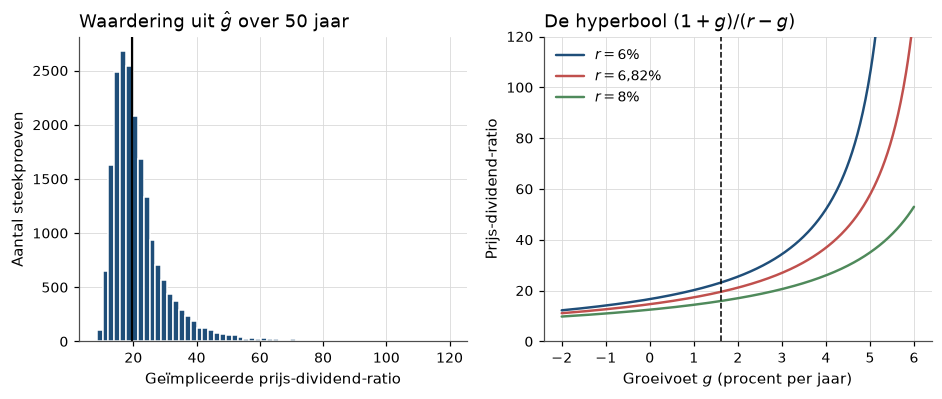

In [7]:
T_plot = 50
pd_hat = pd_hat_by_T[T_plot]                     # dezelfde steekproeven als in de tabel

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

axes[0].hist(pd_hat[np.isfinite(pd_hat) & (pd_hat < 120)], bins=60, edgecolor="white")
axes[0].axvline(pd_true, color="black", lw=1.4)
axes[0].set_xlabel("Geïmpliceerde prijs-dividend-ratio")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].set_title(f"Waardering uit $\\hat g$ over {T_plot} jaar")

g_grid = np.linspace(-0.02, 0.06, 400)
for r_val, label in [(0.06, "$r = 6\\%$"), (0.0682, "$r = 6{,}82\\%$"), (0.08, "$r = 8\\%$")]:
    visible = g_grid < r_val - 0.002
    ratio = np.full_like(g_grid, np.nan)
    ratio[visible] = (1 + g_grid[visible]) / (r_val - g_grid[visible])
    axes[1].plot(g_grid * 100, ratio, lw=1.6, label=label)
axes[1].axvline(g_true * 100, color="black", lw=1.0, ls="--")
axes[1].set_ylim(0, 120)
axes[1].set_xlabel("Groeivoet $g$ (procent per jaar)")
axes[1].set_ylabel("Prijs-dividend-ratio")
axes[1].set_title("De hyperbool $ (1+g)/(r-g) $")
axes[1].legend()

plt.show()

:::{figure} #cel-williams-ddm-verdeling
:label: fig-williams-ddm-verdeling
:width: 100%

Links: de verdeling van de prijs-dividend-ratio die volgt uit een op vijftig
jaar geschatte groeivoet, met de ware waarde als verticale lijn. De verdeling is
scheef naar rechts. Rechts: de verklaring. De prijs-dividend-ratio is een
hyperbool in $g$ met een verticale asymptoot op $g = r$. De gestreepte lijn is de
ware groeivoet. Ver van de asymptoot is de hyperbool vlak en doet een kleine
schattingsfout weinig, vlak ervoor schiet hij omhoog.
:::

De simulatie hield $r$ vast en liet $g$ onzeker. De replicatie vraagt het omgekeerde: beweegt
$r$ zelf?

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** John Burr Williams, *The Theory of Investment Value*, Harvard
University Press 1938 {cite}`Williams1938`, in de gesloten vorm van Gordon en
Shapiro, Management Science 1956 {cite}`GordonShapiro1956`.

**Wat.** Het boek bevat geen tijdreekstoets die we kunnen herhalen. We toetsen de empirische inhoud
van [](#eq-williams-ddm-pd) onder constante $r$: regressies van de reële
dividendgroei en het reële rendement over tien jaar op de log-prijs-dividend-ratio.

**Data hier.** Shillers maandreeks vanaf 1871 via `hap.data.shiller()`,
teruggebracht tot decemberwaarnemingen.

**Verschil met het origineel.** Williams rekende met de hand aan afzonderlijke
bedrijven, zonder index of tijdreeks. Gordons eigen toets {cite}`Gordon1959` is
een cross-sectie waarvan de data niet gratis zijn. Shillers dividendreeks negeert
inkoop van eigen aandelen, wat de gemeten $d_t$ na 1985 te laag maakt.

**Verwachte afwijking.** We verwachten het omgekeerde van Williams: een
dividendcoëfficiënt die niet significant van nul verschilt, en een negatieve,
significante rendementscoëfficiënt met een $R^2$ rond tien procent. Een
significant positieve dividendcoëfficiënt bij een rendementscoëfficiënt rond nul
zou Williams' lezing steunen.
```

De eerste cel bouwt het panel: de log-prijs-dividend-ratio en de gemiddelde
jaarlijkse dividendgroei en rendementen over de tien jaar erna. Ze meldt ook de
uitersten van de prijs-dividend-ratio en de autocorrelatie van de regressor.

In [8]:
# real_price, real_dividend (voortschrijdend twaalfmaands dividend, gedefleerd) en
# real_total_return_price (cum-dividend reële totaalrendementsindex), december.
horizon = 10

pd_ratio = (annual["real_price"] / annual["real_dividend"]).rename("PD")
log_pd = np.log(pd_ratio).rename("log_pd")

future_growth = (
    np.log(annual["real_dividend"].shift(-horizon) / annual["real_dividend"]) / horizon
).rename("dividendgroei")
future_return = (
    np.log(
        annual["real_total_return_price"].shift(-horizon)
        / annual["real_total_return_price"]
    )
    / horizon
).rename("rendement")

panel = pd.concat([log_pd, future_growth, future_return], axis=1).dropna()
print(f"steekproef: {panel.index[0]:%Y} t/m {panel.index[-1]:%Y}, "
      f"{len(panel)} overlappende jaarwaarnemingen")
print(f"PD hele reeks: laagst {pd_ratio.min():.1f} ({pd_ratio.idxmin():%Y}), "
      f"hoogst {pd_ratio.max():.1f} ({pd_ratio.idxmax():%Y})")
print(f"autocorrelatie log PD in het panel: {panel['log_pd'].autocorr():.3f}")
panel.describe().round(4)

steekproef: 1871 t/m 2015, 145 overlappende jaarwaarnemingen
PD hele reeks: laagst 9.9 (1917), hoogst 86.2 (2025)
autocorrelatie log PD in het panel: 0.885


,log_pd,dividendgroei,rendement
count,145.0000,145.0000,145.0000
mean,3.2059,0.0152,0.0664
std,0.4358,0.0281,0.0479
min,2.2880,-0.0671,-0.0424
25%,2.9163,0.0002,0.0373
50%,3.1311,0.0187,0.0684
75%,3.4020,0.0323,0.1021
max,4.4497,0.0840,0.1608


Het panel heeft 145 waarnemingen, van 1871 tot en met 2015. Twee opeenvolgende
tienjaarsperioden delen negen jaar, dus hun residuen hangen samen. De regressies
gebruiken daarom Newey-West-standaardfouten (`hap.newey_west`), die voor zulke
samenhang corrigeren, met negen vertragingen: één per gedeeld jaar. De helling
is de parameter van de regressor, `log_pd`.

In [9]:
fits = {
    column: hap.newey_west(panel[column], panel["log_pd"], lags=horizon - 1)
    for column in ("dividendgroei", "rendement")
}

results = pd.DataFrame(
    {
        "coëfficiënt": [fit.params["log_pd"] for fit in fits.values()],
        "standaardfout": [fit.bse["log_pd"] for fit in fits.values()],
        "t-waarde": [fit.tvalues["log_pd"] for fit in fits.values()],
        "R2": [fit.rsquared for fit in fits.values()],
    },
    index=["reële dividendgroei, 10 jaar vooruit", "reëel totaalrendement, 10 jaar vooruit"],
)
results.round(4)

,coëfficiënt,standaardfout,t-waarde,R2
"reële dividendgroei, 10 jaar vooruit",0.0150,0.0092,1.6346,0.0543
"reëel totaalrendement, 10 jaar vooruit",-0.0375,0.0170,-2.2116,0.1165


De prijs-dividend-ratio voorspelt het rendement, niet de dividendgroei.
De figuur toont beide regressies als puntenwolk. Let op het verschil in helling
tussen het linker- en het rechterpaneel.

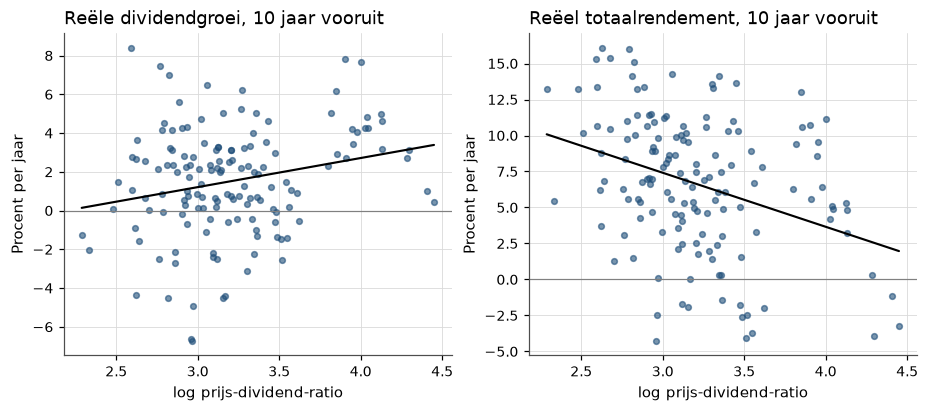

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)

for ax, column, title in [
    (axes[0], "dividendgroei", "Reële dividendgroei"),
    (axes[1], "rendement", "Reëel totaalrendement"),
]:
    ax.scatter(panel["log_pd"], panel[column] * 100, s=14, alpha=0.6)
    slope, intercept = np.polyfit(panel["log_pd"], panel[column] * 100, 1)
    grid_x = np.linspace(panel["log_pd"].min(), panel["log_pd"].max(), 50)
    ax.plot(grid_x, intercept + slope * grid_x, color="black", lw=1.4)
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_xlabel("log prijs-dividend-ratio")
    ax.set_ylabel("Procent per jaar")
    ax.set_title(f"{title}, 10 jaar vooruit")

plt.show()

:::{figure} #cel-williams-ddm-scatter
:label: fig-williams-ddm-scatter
:width: 100%

Elk punt is één decemberwaarneming tussen 1871 en 2015. Links de gerealiseerde
reële dividendgroei over de volgende tien jaar, rechts het gerealiseerde reële
totaalrendement, beide tegen de log-prijs-dividend-ratio van dat moment. Links
een zwakke, niet-significante stijgende lijn, rechts een duidelijk dalende. Als
Williams' aanname klopte, zouden de twee panelen andersom liggen.
:::

De figuur bevestigt de tabel: de rendementswolk helt naar beneden, de
dividendwolk nauwelijks.

Shiller werkte dezelfde gedachte uit tot een eigen maatstaf: de *cyclically
adjusted price-earnings ratio* (CAPE, de koers gedeeld door de gemiddelde reële
winst over tien jaar) {cite}`Shiller2000`. Winst is een betere noemer dan
dividend, omdat zij niet van het uitkeringsbeleid afhangt, en middelen over tien
jaar voorkomt dat één slecht jaar de noemer bepaalt. De codecel herhaalt de
rendementsregressie met log CAPE als regressor. We verwachten dezelfde richting,
een negatieve helling, en een hogere $R^2$, omdat de noemer minder ruis bevat.

In [11]:
cape_panel = pd.concat(
    [np.log(annual["cape"]).rename("log_cape"), future_return], axis=1
).dropna()
fit_cape = hap.newey_west(cape_panel["rendement"], cape_panel["log_cape"], lags=horizon - 1)

pd.DataFrame(
    {
        "coëfficiënt": [fit_cape.params["log_cape"]],
        "t-waarde": [fit_cape.tvalues["log_cape"]],
        "R2": [fit_cape.rsquared],
        "n": [int(fit_cape.nobs)],
    },
    index=["log CAPE → reëel rendement, 10 jaar vooruit"],
).round(4)

,coëfficiënt,t-waarde,R2,n
"log CAPE → reëel rendement, 10 jaar vooruit",-0.0592,-4.5173,0.2404,135


Zo komt het uit: de helling is negatief en de $R^2$ twee keer zo hoog. De steekproef begint pas in 1881, omdat CAPE tien jaar winst nodig heeft.
Het sterkere verband bewijst weinig, want CAPE is met kennis van de hele reeks als
voorspeller gekozen.

Wat betekent één log-punt? Een prijs-dividend-ratio van 54 in plaats van 20
($20 \times 2{,}72 \approx 54$). De identiteit in logs zegt waar dat log-punt
heen moet. Bij benadering is de log-ratio van vandaag de som van tien jaar
log-dividendgroei, min de som van tien jaar log-rendementen, plus de log-ratio
over tien jaar. Regresseren we elk van die drie op de log-ratio van vandaag, dan
tellen de hellingen op tot ongeveer één. De tabel rekent de jaarhellingen om naar
tien jaar.

| deel van het log-punt | berekening | log-punt |
|---|---|---|
| snellere dividendgroei | $10 \times 0{,}015$ | 0,15 |
| lager rendement | $10 \times 0{,}0375$ | 0,38 |
| hogere ratio over tien jaar (rest) | $1 - 0{,}15 - 0{,}38$ | 0,47 |
| totaal | | 1 |

Het rendement draagt ruim twee keer zoveel als de dividendgroei, en de ratio
blijft lang hoog. De optelling is bij benadering: de exacte log-vorm van Campbell
en Shiller weegt latere jaren met een factor iets onder één en bevat een kleine
term voor het dividendrendement. De 0,47 is dus een orde van grootte.

```{warning}
De 145 overlappende waarnemingen zijn samen ongeveer veertien onafhankelijke
tienjaarsperioden. Newey-West corrigeert daar in eindige steekproeven maar
gedeeltelijk voor.

Bovendien is de regressor sterk persistent: de autocorrelatie van de
log-prijs-dividend-ratio in het panel is 0,89. In een korte steekproef wordt die
persistentie te laag geschat. Een onverwachte koersstijging verhoogt tegelijk de
ratio en het rendement van dat jaar, dus de schokken in regressor en rendement
bewegen samen. Via die samenhang lekt de te lage persistentie in de helling: de
rendementshelling valt negatiever uit dan de ware (de Stambaugh-bias
{cite}`Stambaugh1999`). Lees deze $t$-waarden als een aanwijzing voor de richting,
niet als bewijs.
```

De laatste cel zet de uitkomst voor de prijs-dividend-ratio naast wat Williams'
lezing eist en wat het replicatieblok verwachtte.

In [12]:
growth_fit, return_fit = results.iloc[0], results.iloc[1]
pd.DataFrame(
    {
        "Williams (constante r)": ["positief, significant", "groot", "nul", "nul"],
        "verwacht": ["niet significant", "klein", "negatief, significant", "rond 10%"],
        "hier": [
            f"{growth_fit['coëfficiënt']:.3f} (t = {growth_fit['t-waarde']:.2f})",
            f"{growth_fit['R2']:.2f}",
            f"{return_fit['coëfficiënt']:.3f} (t = {return_fit['t-waarde']:.2f})",
            f"{return_fit['R2']:.2f}",
        ],
    },
    index=["dividendgroei: coëfficiënt", "dividendgroei: R2",
           "rendement: coëfficiënt", "rendement: R2"],
)

,Williams (constante r),verwacht,hier
dividendgroei: coëfficiënt,"positief, significant",niet significant,0.015 (t = 1.63)
dividendgroei: R2,groot,klein,0.05
rendement: coëfficiënt,nul,"negatief, significant",-0.038 (t = -2.21)
rendement: R2,nul,rond 10%,0.12


**Geslaagd.** Alle drie de verwachtingen uit het replicatieblok komen uit (tabel
hierboven): de dividendcoëfficiënt is niet significant, de rendementscoëfficiënt
is negatief en significant, en de $R^2$ ligt rond tien procent. Het teken van de dividendcoëfficiënt klopt
wel met Williams. Voor het model van Williams is de uitkomst toch
een verwerping: $r$ is geen constante maar een tijdreeks.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Veel. Het dividend discount model rust op een
identiteit die niet breekt, en legt vast dat een prijs alleen beweegt als
verwachte uitkeringen of discontovoeten bewegen. Zo wordt elke
waarderingsdiscussie een discussie over welke van de twee het is. Het
Gordon-model gaf de praktijk een werkbare vuistregel: verwacht rendement is
dividendrendement plus groei. De PVGO liet zien dat groei en waarde niet
hetzelfde zijn.

**Waar het breekt.** Niet in de boekhoudkundige identiteit maar in het model van
Williams, in de aanname van constante $r$. De prijs-dividend-ratio voorspelt de
tienjaarsgroei van dividenden nauwelijks ($R^2 \approx 5\%$) en het
tienjaarsrendement wel ($R^2 \approx 12\%$). Volgens [](#eq-williams-ddm-pd)
beweegt $r$ dus. Ruis in de schatting van $g$ verklaart dat niet: de simulatie liet
waarderingen zien die tot een factor twee naast zitten, maar de ratio liep van 10
tot 86, en haar beweging voorspelt rendementen, geen dividenden. Het enige symbool
dat Williams als gegeven nam, draagt ruim twee keer zoveel van de beweging als de
dividendgroei.

**Risico of vergissing?** Beide lezingen passen bij dezelfde tabel. De
Chicago-lezing: $r$ is de vergoeding voor aandelenrisico, hoog als mensen arm en
bang zijn, laag als ze rijk zijn. Voorspelbare rendementen zijn dan een goed
werkende markt. De Yale-lezing: mensen extrapoleren de laatste jaren, betalen te
veel na goede jaren en te weinig na slechte, en de voorspelbaarheid is de trage
correctie van die vergissing. Beide voorspellen dezelfde negatieve helling. Pas
een theorie over $r$ scheidt ze. In 2013, toen Fama en Shiller samen de
Nobelprijs kregen, was het vak daar nog niet uit ([](#05-33-fama-vs-shiller)).

Bij theorie of feit vraagt de reeks steeds: is dit een theorie die getoetst
wordt, of een feit dat op een verklaring wacht? Bachelier leverde een *feit*,
koersen als random walk. Williams leverde een identiteit die waar is zonder iets
uit te sluiten, en een model met een constante $r$ dat toetsbaar is. Zo getoetst
en verworpen werd het pas decennia later, na het CAPM, dat [](#00-00-setup) het
eerste getoetste model van het vak noemt.

**Wat er daarna kwam.** Williams had geen theorie van $r$, maar wel het inzicht
dat er een nodig is. Markowitz verplaatste de vraag: niet langer wat één aandeel
waard is, maar welke portefeuille een belegger moet houden en welk risico daarbij
telt. Zie [](#01-04-markowitz).

## Oefeningen

:::{exercise}
:label: ex-williams-ddm-instap

**Instap: het toy-voorbeeld gevarieerd.** Neem het toy-voorbeeld, maar laat het
dividend vanaf jaar 4 met 4% groeien in plaats van 5%.

1. Bereken met de hand de eindwaarde op $t=0$, de prijs $p_0$ en het aandeel van
   de eindwaarde in de prijs.
2. Met hoeveel procent daalt de prijs, en waarom zoveel?
:::

:::{solution} ex-williams-ddm-instap
:class: dropdown

**(1)** De eindwaarde op $t=3$ is $1{,}331 \times 1{,}04/0{,}06 = 23{,}0707$.
Terugrekenen met $1{,}331$ laat die factor wegvallen: $1{,}04/0{,}06 = 17{,}3333$.
De prijs is $3{,}00 + 17{,}33 = 20{,}33$, en de eindwaarde is daarvan 85,2%.

In [13]:
g_late_alt = 0.04
terminal_instap = dividends[-1] * (1 + g_late_alt) / (r - g_late_alt)
terminal_pv_instap = terminal_instap / (1 + r) ** n
price_instap = discounted.sum() + terminal_pv_instap

pd.Series({
    "eindwaarde op t=0": terminal_pv_instap,
    "prijs p_0": price_instap,
    "aandeel eindwaarde": terminal_pv_instap / price_instap,
    "verandering prijs": price_instap / price - 1,
}).round(4)

eindwaarde op t=0     17.3333
prijs p_0             20.3333
aandeel eindwaarde     0.8525
verandering prijs     -0.1528
dtype: float64

**(2)** De prijs daalt met ruim 15%, van 24,00 naar 20,33. De eindwaarde daalt
17,5%, van 21,00 naar 17,33: één procentpunt minder groei maakt $r - g$ een vijfde
groter, en $d_4$ wordt iets kleiner. Omdat de eindwaarde het grootste deel van de prijs is, werkt
die daling bijna volledig door. Wat dit leert: de waardering hangt vooral af van
de groei in de verre toekomst, en juist daarover weet niemand iets.
:::

:::{exercise}
:label: ex-williams-ddm-1

**De bel die het model toestaat.** Neem $r = 8\%$, $d_0 = 2{,}00$ en constante
dividendgroei $g = 3\%$.

1. Bereken de fundamentele waarde $p^{f}_0$ en de fundamentele
   prijs-dividend-ratio.
2. Laat zien dat $p_t = p^{f}_t + B_t$ met $\E_t[B_{t+1}] = (1+r) B_t$ voldoet
   aan $p_t = \E_t[d_{t+1}+p_{t+1}]/(1+r)$.
3. Stel dat $p_0 = p^{f}_0 + 10$ en dat de bel exact zijn verwachte pad volgt.
   Bereken de prijs-dividend-ratio na 10, 25 en 50 jaar. Vanaf welk jaar is meer
   dan de helft van de prijs bel?
:::

:::{solution} ex-williams-ddm-1
:class: dropdown

**(1)** $p^f_0 = d_0(1+g)/(r-g) = 2{,}00 \times 1{,}03/0{,}05 = 41{,}20$, dus
$\mathrm{PD} = 20{,}6$.

**(2)** Vul in: $\E_t[d_{t+1} + p^f_{t+1} + B_{t+1}]/(1+r)
= \left(\E_t[d_{t+1}+p^f_{t+1}] + (1+r)B_t\right)/(1+r) = p^f_t + B_t$, omdat
$p^f$ per constructie aan de vergelijking voldoet. De bel is een tweede, even
geldige oplossing van dezelfde differentievergelijking.

**(3)** De codecel volgt fundament en bel en zoekt het eerste jaar waarin de bel
groter is.

In [14]:
r_ex, d0_ex, g_ex, b0 = 0.08, 2.00, 0.03, 10.0

t_grid = np.array([0, 10, 25, 50])
d_t = d0_ex * (1 + g_ex) ** t_grid
p_f = d_t * (1 + g_ex) / (r_ex - g_ex)
b_t = b0 * (1 + r_ex) ** t_grid

bubble = pd.DataFrame(
    {
        "jaar": t_grid,
        "fundamenteel": p_f,
        "bel": b_t,
        "prijs": p_f + b_t,
        "PD-ratio": (p_f + b_t) / d_t,
        "aandeel bel": b_t / (p_f + b_t),
    }
).set_index("jaar").round(3)

crossing_year = None
for year in range(200):
    bubble_value = b0 * (1 + r_ex) ** year
    fundamental_value = d0_ex * (1 + g_ex) ** (year + 1) / (r_ex - g_ex)
    if bubble_value > fundamental_value:           # bel groter dan fundament
        crossing_year = year
        break

print(f"de bel is meer dan de helft van de prijs vanaf jaar {crossing_year}")
bubble

de bel is meer dan de helft van de prijs vanaf jaar 30


,fundamenteel,bel,prijs,PD-ratio,aandeel bel
jaar,,,,,
0,41.200,10.000,51.200,25.600,0.195
10,55.369,21.589,76.959,28.632,0.281
25,86.264,68.485,154.748,36.954,0.443
50,180.617,469.016,649.633,74.093,0.722


De prijs-dividend-ratio loopt van 25,6 via 28,6 en 37,0 naar 74,1 na vijftig
jaar, en vanaf jaar 30 is meer dan de helft van de prijs bel. De bel groeit met
8% per jaar en het fundament met 3%, dus het aandeel van de bel loopt naar één.
Wat dit leert: de transversaliteitsvoorwaarde is de aanname die verbiedt dat de
prijs-dividend-ratio voor altijd blijft stijgen, en dat is een aanname over
gedrag, niet over wiskunde.
:::

:::{exercise}
:label: ex-williams-ddm-2

**Groei die waarde vernietigt.** Een bedrijf verwacht volgend jaar een winst per
aandeel van $e_1 = 5{,}00$. De discontovoet is $r = 9\%$.

1. Bereken de prijs en de PVGO voor $\mathrm{ROE} \in \{6\%, 9\%, 12\%\}$ bij een
   inhoudingspercentage $b = 0{,}5$.
2. Het bedrijf verhoogt $b$ naar $0{,}6$. Voor welke $\mathrm{ROE}$ stijgt de
   prijs, en waarom?
:::

:::{solution} ex-williams-ddm-2
:class: dropdown

De codecel past [](#eq-williams-ddm-pvgo) toe bij beide inhoudingspercentages.

In [15]:
e1_ex, r_ex2 = 5.00, 0.09

rows_pvgo = []
for roe in (0.06, 0.09, 0.12):
    price_half = (1 - 0.5) * e1_ex / (r_ex2 - 0.5 * roe)
    price_more = (1 - 0.6) * e1_ex / (r_ex2 - 0.6 * roe)
    rows_pvgo.append(
        {
            "ROE": roe,
            "prijs bij b = 0,5": price_half,
            "PVGO bij b = 0,5": price_half - e1_ex / r_ex2,
            "prijs bij b = 0,6": price_more,
        }
    )

pd.DataFrame(rows_pvgo).set_index("ROE").round(4)

,"prijs bij b = 0,5","PVGO bij b = 0,5","prijs bij b = 0,6"
ROE,,,
0.06,41.6667,-13.8889,37.0370
0.09,55.5556,0.0000,55.5556
0.12,83.3333,27.7778,111.1111


**(1)** Zonder groei is het bedrijf $e_1/r = 55{,}56$ waard. Bij
$\mathrm{ROE} = 6\%$ is de prijs $2{,}50/0{,}06 = 41{,}67$ en de PVGO $-13{,}89$;
bij 9% is de prijs $55{,}56$ en de PVGO nul; bij 12% is de prijs
$2{,}50/0{,}03 = 83{,}33$ en de PVGO $27{,}78$.

**(2)** Meer inhouden verhoogt de prijs alleen bij $\mathrm{ROE} = 12\% > r$
(naar 111,11) en verlaagt hem bij 6% (naar 37,04). Bij $\mathrm{ROE} = r$ maakt $b$
niets uit: een investering tegen de discontovoet heeft een netto contante
waarde van nul. Dat lijkt op de stelling van Miller en Modigliani
{cite}`MillerModigliani1961` (bij gegeven investeringen raakt het uitkeringsbeleid
de waarde niet), maar is niet hetzelfde: hier verandert $b$ juist de investering.
Wat dit leert: groei is in dit model geen aparte
bron van waarde, maar een herverpakking van $\mathrm{ROE} - r$.
:::

:::{exercise}
:label: ex-williams-ddm-3

**De replicatie op een andere steekproef.** Herhaal de twee regressies uit de
replicatie op de naoorlogse steekproef (waarnemingen vanaf december 1945) en op
een horizon van vijf jaar in plaats van tien. Rapporteer coëfficiënt,
$t$-waarde en $R^2$ voor beide afhankelijke variabelen. Verandert de conclusie
over welk van de twee kanalen beweegt?
:::

:::{solution} ex-williams-ddm-3
:class: dropdown

De codecel herhaalt de regressies voor vier combinaties van steekproef en horizon.

In [16]:
def horizon_panel(frame, h, start=None):
    """Overlapping h-year forward growth and return, against log PD."""
    sub = frame if start is None else frame.loc[start:]
    lpd = np.log(sub["real_price"] / sub["real_dividend"]).rename("log_pd")
    growth_h = (np.log(sub["real_dividend"].shift(-h) / sub["real_dividend"]) / h).rename(
        "dividendgroei"
    )
    return_h = (
        np.log(sub["real_total_return_price"].shift(-h) / sub["real_total_return_price"])
        / h
    ).rename("rendement")
    return pd.concat([lpd, growth_h, return_h], axis=1).dropna()


rows_ex = []
for label, h, start in [
    ("1871–, h=10", 10, None),
    ("1945–, h=10", 10, "1945"),
    ("1871–, h=5", 5, None),
    ("1945–, h=5", 5, "1945"),
]:
    sample = horizon_panel(annual, h, start)
    for column in ("dividendgroei", "rendement"):
        fit = hap.newey_west(sample[column], sample["log_pd"], lags=h - 1)
        rows_ex.append(
            {
                "steekproef": label,
                "variabele": column,
                "coëfficiënt": fit.params.iloc[1],
                "t-waarde": fit.tvalues.iloc[1],
                "R2": fit.rsquared,
                "n": int(fit.nobs),
            }
        )

pd.DataFrame(rows_ex).set_index(["steekproef", "variabele"]).round(4)

coëfficiënt  t-waarde      R2    n
steekproef  variabele                                        
1871–, h=10 dividendgroei       0.0150    1.6346  0.0543  145
            rendement          -0.0375   -2.2116  0.1165  145
1945–, h=10 dividendgroei       0.0102    0.9791  0.0401   71
            rendement          -0.0634   -3.4964  0.2685   71
1871–, h=5  dividendgroei       0.0263    2.0237  0.0583  150
            rendement          -0.0446   -2.2794  0.0780  150
1945–, h=5  dividendgroei       0.0062    0.4585  0.0065   76
            rendement          -0.0679   -3.0778  0.1791   76

De rendementscoëfficiënt is in alle vier de varianten negatief, en naoorlogs
sterker: $-0{,}063$ met $t = -3{,}50$ op tien jaar. De dividendcoëfficiënt is
overal klein en alleen over de volle steekproef op vijf jaar net significant
($0{,}026$, $t = 2{,}02$). Ook dan reageert de dividendgroei over vijf jaar met
$5 \times 0{,}026 \approx 0{,}13$ log-punt op één log-punt prijs-dividend-ratio,
tegen $5 \times 0{,}045 \approx 0{,}22$ voor het rendement. De conclusie verandert
niet.

De $t$-waarden schommelen wel sterk: 71 naoorlogse waarnemingen op tien jaar zijn
nog geen acht onafhankelijke perioden. Wat dit leert: de richting van het
resultaat is robuust, de sterkte niet, omdat een helling met zo weinig
onafhankelijke perioden net zo slecht te meten is als een gemiddeld rendement.
:::